## 文本分类--中文情感分析：加载数据

这里使用数据集：https://huggingface.co/datasets/lansinuote/ChnSentiCorp

In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

from datasets import load_dataset

### 1. 加载数据

In [2]:
ds = load_dataset("lansinuote/ChnSentiCorp")

In [3]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9600
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1200
    })
})

可以看到其`train`有9600条，`validation`和`test`各有1200条。

In [4]:
# 查看数据的特征
ds["train"].features

{'text': Value(dtype='string', id=None),
 'label': ClassLabel(names=['negative', 'positive'], id=None)}

In [5]:
ds["train"][1]

{'text': '15.4寸笔记本的键盘确实爽，基本跟台式机差不多了，蛮喜欢数字小键盘，输数字特方便，样子也很美观，做工也相当不错',
 'label': 1}

### 2. 数据处理

#### 2.1 添加文字的label_name

In [6]:
ds["train"].features["label"].int2str([0, 1, 1, 0])

['negative', 'positive', 'positive', 'negative']

In [7]:
def add_label_name(batch):
    label_name = ds["train"].features["label"].int2str(batch["label"])
    return {"label_name": label_name}                

In [8]:
ds["train"].column_names

['text', 'label']

In [9]:
# 使用ds.map()方法，给数据集添加列
ds = ds.map(add_label_name, batched=True, batch_size=1000)

In [10]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name'],
        num_rows: 9600
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name'],
        num_rows: 1200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name'],
        num_rows: 1200
    })
})

**现在数据集就加上`label_name`字段了。**

In [11]:
ds["train"][1]

{'text': '15.4寸笔记本的键盘确实爽，基本跟台式机差不多了，蛮喜欢数字小键盘，输数字特方便，样子也很美观，做工也相当不错',
 'label': 1,
 'label_name': 'positive'}

#### 2.2 分词

In [12]:
model_name = "bert-base-chinese"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [13]:
def tokenize_handle(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

In [14]:
# map调用
ds = ds.map(tokenize_handle, batched=True, batch_size=1000)

Map:   0%|          | 0/9600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

In [15]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9600
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1200
    })
})

### 3. 保存数据到磁盘

In [16]:
ds_file_path = "../../../data/datasets/ChnSentiCorp/ds"

In [17]:
# 保存
ds.save_to_disk(ds_file_path)

Saving the dataset (0/1 shards):   0%|          | 0/9600 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1200 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1200 [00:00<?, ? examples/s]

In [18]:
# 查看文件
!ls {ds_file_path}

dataset_dict.json test              train             validation


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [19]:
# 后续加载数据
# ds_file_path = "../../../data/datasets/ChnSentiCorp/ds"

# 从磁盘中加载数据集
# ds = load_from_disk(ds_file_path)

### 4. 查看数据的分布

#### 4.1 查看训练集正面和负面的条数

In [20]:
ds.set_format("pandas")

In [21]:
train_df = ds["train"][:]
train_df.head()

,text,label,label_name,input_ids,token_type_ids,attention_mask
0,选择珠江花园的原因就是方便，有电动扶梯直接到达海边，周围餐馆、食廊、商场、超市、摊位一应俱全...,1,positive,"[101, 6848, 2885, 4403, 3736, 5709, 1736, 4638...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,15.4寸笔记本的键盘确实爽，基本跟台式机差不多了，蛮喜欢数字小键盘，输数字特方便，样子也很...,1,positive,"[101, 8115, 119, 125, 2189, 5011, 6381, 3315, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,房间太小。其他的都一般。。。。。。。。。,0,negative,"[101, 2791, 7313, 1922, 2207, 511, 1071, 800, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,"1.接电源没有几分钟,电源适配器热的不行. 2.摄像头用不起来. 3.机盖的钢琴漆，手不能摸...",0,negative,"[101, 122, 119, 2970, 4510, 3975, 3766, 3300, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,"今天才知道这书还有第6卷,真有点郁闷:为什么同一套书有两种版本呢?当当网是不是该跟出版社商量...",1,positive,"[101, 791, 1921, 2798, 4761, 6887, 6821, 741, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [22]:
# 根据标签名统计个数，升序排列
train_df["label_name"].value_counts(ascending=True)

label_name
positive    4799
negative    4801
Name: count, dtype: int64

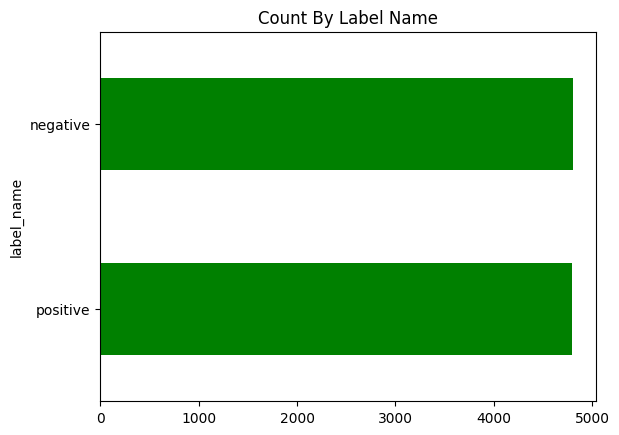

In [23]:
# 直接画出图形
train_df["label_name"].value_counts(ascending=True).plot.barh(color="green")
plt.title("Count By Label Name")
plt.show()

#### 4.2 查看数据中文本的长度

In [24]:
train_df["Text Length"] = train_df["text"].apply(len)

In [25]:
train_df.head()

,text,label,label_name,input_ids,token_type_ids,attention_mask,Text Length
0,选择珠江花园的原因就是方便，有电动扶梯直接到达海边，周围餐馆、食廊、商场、超市、摊位一应俱全...,1,positive,"[101, 6848, 2885, 4403, 3736, 5709, 1736, 4638...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",106
1,15.4寸笔记本的键盘确实爽，基本跟台式机差不多了，蛮喜欢数字小键盘，输数字特方便，样子也很...,1,positive,"[101, 8115, 119, 125, 2189, 5011, 6381, 3315, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",56
2,房间太小。其他的都一般。。。。。。。。。,0,negative,"[101, 2791, 7313, 1922, 2207, 511, 1071, 800, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",20
3,"1.接电源没有几分钟,电源适配器热的不行. 2.摄像头用不起来. 3.机盖的钢琴漆，手不能摸...",0,negative,"[101, 122, 119, 2970, 4510, 3975, 3766, 3300, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",64
4,"今天才知道这书还有第6卷,真有点郁闷:为什么同一套书有两种版本呢?当当网是不是该跟出版社商量...",1,positive,"[101, 791, 1921, 2798, 4761, 6887, 6821, 741, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",70


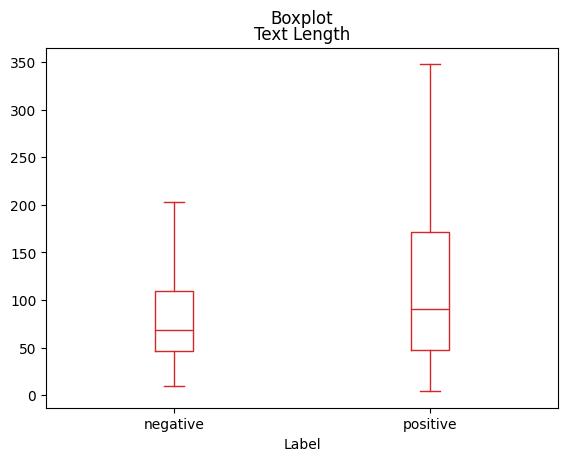

In [26]:
# 图形展示：箱体图
train_df.boxplot("Text Length", by="label_name", grid=False, showfliers=False, color="C3")
plt.suptitle("Boxplot")
plt.xlabel("Label")
plt.show()

In [27]:
# 最后重置数据集的格式
ds.reset_format()

In [28]:
type(ds["train"][:])

dict